# nb_05c — Reflection-equivariant read-out, by construction (E2)

> **Archived transductive analysis; not current workshop evidence.** The historical narrative below is retained for method provenance only. Its numerical values must not be cited until the experiment scripts are refactored to consume a hash-verified, fold-local checkpoint and rerun.


**E1** established the informative null: the frozen S-JEPA does *not* encode the signed left–right axis as a decodable, sign-flipping quantity (learned $\approx$ floor; mirror slope $\approx-0.70$). **E2** asks the constructive question:

> If we *impose* reflection-equivariance on the **read-out**, do we recover exact antisymmetry — and does the axis become more decodable from the *same* frozen tokens?

> **Responsible-use notice.** All results in this notebook are **transductive** — the
> S-JEPA encoder was trained on the very sequences being evaluated — so they carry
> *internal validity only* and make **no** claim of generalization to new sources or
> people. The **source video** (not the clip, not the individual) is the independent unit
> of analysis. The dataset's condition folders (`normal`, `parkinsons`, `stroke`,
> `myopathic`, `cerebralpalsy`) are **dataset annotations, not diagnoses**. The dataset's
> official distribution provides annotations and public video URLs, not raw video; this
> analysis uses derived pose sequences, infers no identity, and redistributes no raw or
> identity-bearing frames. **No institutional ethics determination or completed data-use
> review is yet on record; both must be resolved before submission.**

## Source-held-out evaluation boundary

![One source video, one role, zero cross-fold leakage](../images/22_inductive_source_split.svg)

These laterality probes are consumers of a representation, so grouping only their ridge or MLP readout is insufficient. A result is **inductive** only when the complete encoder/predictor was trained inside the outer source fold and the probe was tuned on validation sources before the test sources were opened. Every result must carry the source-manifest hash, split hash, outer fold, model seed, objective, and checkpoint hash.

**Current status: blocked pending fold-local artifacts.** The former embedded values came from the retired all-corpus checkpoint and missing `work/experiments` scripts. They have been cleared and are not workshop evidence. Re-enable this notebook only after those scripts consume protocol-v2 assignments and assert that no test `video_id` appears in representation training. Folder labels are observational dataset annotations, not diagnoses.


## 1. Frame averaging over $G=\{I,M\}$

Let $A(x)$ be the per-pair laterality feature of the frozen encoder. Average over the order-2 group (Puny et al., 2022):

$$ \Phi(x) = A(x) - A(Mx)\quad(\text{antisymmetric}),\qquad \Psi(x) = A(x) + A(Mx)\quad(\text{symmetric}). $$

Because $M^2=I$, $\;\Phi(Mx) = A(Mx)-A(x) = -\Phi(x)$ **exactly**, and $\Psi(Mx)=+\Psi(x)$ **exactly**. A *linear* read-out $w^\top\Phi$ therefore satisfies $w^\top\Phi(Mx) = -\,w^\top\Phi(x)$: **mirror slope $=-1$ for *any* weights $w$** — the antisymmetry is a property of the construction, not of training (`../neurips-laterality/docs/figures/fig4_construction.svg`).

The target $y$ is itself exactly antisymmetric, so a **symmetric** read-out on $\Psi$ *cannot* track its sign — a clean falsification control.

**Isolating the cause.** To show any gain comes from the *constraint* and not from capacity or the extra mirror pass, we add two learnable heads on the frozen tokens:
- `eq_mlp`: $s(x)=m(A)-m(A_{\mathrm{mir}})$ with a **shared** MLP $m$ → exactly antisymmetric for any $m$;
- `free_mlp`: an **untied** MLP on $[A;A_{\mathrm{mir}}]$ with $\ge$ the same capacity, seeing both passes but free to ignore the symmetry.

## How to read the progress display

Four E2 stages run only when the fold-local opt-in, refactored script, and one
matching checkpoint are present. Otherwise the display ends as not run rather
than implying a result. A completed bar means the regenerated artifact and its
exactness assertions were checked; the reported lanes determine the verdict.


In [1]:
import json, os, subprocess, sys, textwrap
from pathlib import Path

def find_experiment_dir(start=None):
    candidates = []
    if os.getenv("ALEXPOSE_ROOT"):
        env_root = Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        candidates.extend([env_root, env_root / "experiments" / "sjepa" / "gavd5-drift"])
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        candidates.extend([base, base / "experiments" / "sjepa" / "gavd5-drift"])
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "data-gavd").is_dir():
            return candidate
    raise FileNotFoundError(f"Cannot locate gavd5-drift from {start}; set ALEXPOSE_ROOT.")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"
PY = EXPERIMENT_DIR / ".venv" / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
PY = str(PY if PY.exists() else sys.executable)   # fall back to the running kernel
ART = EXPERIMENT_DIR / "work" / "artifacts" / "real"

def run_experiment(script_relpath):
    """Run a validated standalone experiment script; it regenerates its JSON artifact."""
    script = EXPERIMENT_DIR / script_relpath
    print(f"running {script.name} with {PY} ...")
    proc = subprocess.run([PY, str(script)], cwd=str(EXPERIMENT_DIR),
                          capture_output=True, text=True)
    print(proc.stdout[-4000:])
    if proc.returncode != 0:
        print("STDERR (tail):\n", proc.stderr[-4000:])
        raise RuntimeError(f"{script.name} exited {proc.returncode}")
    return proc

def approx(a, b, tol):
    return abs(float(a) - float(b)) <= tol


# Retired scripts used an all-corpus checkpoint.  Running them implicitly would
# recreate transductive evidence, so laterality execution requires an explicit
# opt-in plus both the refactored scripts and exactly one fold-local checkpoint.
LATERALITY_REQUIRED_SCRIPTS = ['work/experiments/e2_equivariant_readout.py']
LATERALITY_SCRIPT_PATHS = [EXPERIMENT_DIR / item for item in LATERALITY_REQUIRED_SCRIPTS]
LATERALITY_MODE = os.getenv("GAVD_MODE", "real")
LATERALITY_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
LATERALITY_SEED = int(os.getenv("SJEPA_MODEL_SEED", "42"))
LATERALITY_CHECKPOINTS = sorted((
    EXPERIMENT_DIR / "work" / "artifacts" / LATERALITY_MODE / "checkpoints"
).glob(f"sjepa_outer_fold_{LATERALITY_FOLD}_seed_{LATERALITY_SEED}_*.pt"))
LATERALITY_OPT_IN = os.getenv("LATERALITY_ENABLE_FOLD_LOCAL", "0") == "1"
LATERALITY_READY = (
    LATERALITY_OPT_IN
    and all(item.is_file() for item in LATERALITY_SCRIPT_PATHS)
    and len(LATERALITY_CHECKPOINTS) == 1
)
if not LATERALITY_READY:
    missing = [str(item.relative_to(EXPERIMENT_DIR)) for item in LATERALITY_SCRIPT_PATHS if not item.is_file()]
    print(
        "BLOCKED — laterality result not executed. "
        f"explicit_fold_local_opt_in={LATERALITY_OPT_IN}; "
        f"missing_refactored_scripts={missing}; "
        f"matching_fold_checkpoints={len(LATERALITY_CHECKPOINTS)}."
    )

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

readout_progress = NotebookTaskProgress('Equivariant-readout progress', "stage", refresh_seconds=0.5)
readout_progress.start(4, profile=LATERALITY_MODE)
if not LATERALITY_READY:
    readout_progress.finish_skipped(
        "Fold-local opt-in, refactored scripts, and exactly one matching checkpoint are required.",
        status="Preflight complete — laterality workflow not run",
    )


BLOCKED — laterality result not executed. explicit_fold_local_opt_in=False; missing_refactored_scripts=['work\\experiments\\e2_equivariant_readout.py']; matching_fold_checkpoints=6.


In [2]:
if LATERALITY_READY:
    with readout_progress.unit(1, "Run the fold-local E2 experiment"):
        # Re-run E2 end-to-end (regenerates idea9_equivariant_readout_result.json).
        run_experiment('work/experiments/e2_equivariant_readout.py')
        res = json.loads((ART / 'idea9_equivariant_readout_result.json').read_text())
        prim = res['primary_cohort']
        print('fingerprint', res['fingerprint'][:12], '| primary',
              prim['n_sequences'], 'seq /', prim['n_sources'], 'sources')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [3]:
if LATERALITY_READY:
    with readout_progress.unit(2, "Summarize equivariant readout lanes"):
        # ---- Table 2: read-out lanes on 626 primary (repeated-CV R2 + mirror slope)
        lanes, slopes, ci = prim['lanes'], prim['mirror_slopes'], prim['repeated_cv_ci95']
        def band(k):
            if k in ci:
                d = ci[k]; return f"{d['mean']:.3f} [{d['ci95_lo']:.3f}, {d['ci95_hi']:.3f}]"
            return f"{lanes[k]['r2']:.3f}"
        print('E2 read-out — 626 primary')
        print(f"  A  — free ridge            R2={band('A_free'):24s} slope={slopes['A_free']:+.4f}")
        print(f"  Phi— frame-avg, learned    R2={band('Phi_learned'):24s} slope={slopes['Phi_learned']:+.7f}")
        print(f"  Phi— frame-avg, untrained  R2={band('Phi_floor'):24s} slope={slopes['Phi_floor']:+.7f}")
        print(f"  Psi— symmetric part        R2={lanes['Psi_learned']['r2']:+.3f}                    slope={slopes['Psi_learned']:+.4f}")
        print(f"  B  — raw ceiling           R2={lanes['B_raw']['r2']:.3f}")
        sc = ci['Phi_learned_sign_consistency']
        print(f"\n  Phi_learned sign consistency {sc['mean']:.3f} [{sc['ci95_lo']:.3f}, {sc['ci95_hi']:.3f}]")
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [4]:
if LATERALITY_READY:
    with readout_progress.unit(3, "Inspect capacity-matched controls"):
        # ---- Learnable-head controls: the gain is the CONSTRAINT, not capacity/extra pass
        h = prim['learnable_heads']
        print(f"  eq_mlp   (shared m: s=m(A)-m(A_mir))  R2={h['eq_mlp']['r2']:+.3f}  slope={h['eq_mlp']['mirror_slope']:+.7f}")
        print(f"  free_mlp (untied, >=capacity)         R2={h['free_mlp']['r2']:+.3f}  slope={h['free_mlp']['mirror_slope']:+.3f}")
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


In [5]:
if LATERALITY_READY:
    with readout_progress.unit(4, "Verify the E2 artifact contract"):
        # ---- Assert the paper's E2 numbers trace to this freshly-written artifact
        Phi = ci['Phi_learned']; Afree = ci['A_free']; Pfloor = ci['Phi_floor']
        assert approx(Phi['mean'], 0.273, 0.01), Phi
        assert approx(Afree['mean'], 0.198, 0.01), Afree
        assert approx(slopes['Phi_learned'], -1.0, 1e-4), slopes['Phi_learned']
        assert approx(slopes['Psi_learned'], +1.0, 1e-4), slopes['Psi_learned']
        assert approx(lanes['Psi_learned']['r2'], 0.015, 0.01), lanes['Psi_learned']['r2']
        assert approx(h['free_mlp']['r2'], 0.047, 0.02), h['free_mlp']
        # (1) built-in beats free with DISJOINT stability intervals (partition-stability heuristic)
        assert Phi['ci95_lo'] > Afree['ci95_hi'], (Phi, Afree)
        # (2) learned edges the untrained floor but intervals OVERLAP -> learning benefit suggestive
        assert Phi['mean'] > Pfloor['mean'] and Phi['ci95_lo'] < Pfloor['ci95_hi'], (Phi, Pfloor)
        print('OK — E2 numbers match the paper; built-in beats free (disjoint intervals);')
        print('     the learning-vs-geometry gap is honestly suggestive (overlapping intervals).')
    readout_progress.complete(status='Equivariant-readout workflow complete')
else:
    print("SKIPPED — fold-local laterality prerequisites are not satisfied.")


SKIPPED — fold-local laterality prerequisites are not satisfied.


## 2. Reading the result

Two observations stand out. **(1) Built-in beats free**, with *disjoint* stability intervals ($\Phi\approx0.273$ vs $A\approx0.198$; a partition-stability heuristic, not a significance test): imposing the geometry unlocks decodable structure the free read-out does not reach from the *same* frozen encoder ($\Phi$ additionally evaluates the mirrored pass $A(Mx)$). **(2) The controls are consistent with the antisymmetric constraint — not capacity or the extra pass — as the source of the gain (they do not isolate a causal decomposition).** The symmetric $\Psi$ cannot predict an antisymmetric target ($\approx0.015$, slope $+1$); the shared-map `eq_mlp` is exactly antisymmetric and a *linear* $\Phi$ is already optimal (nonlinearity adds nothing); the untied `free_mlp` — $\ge$ the same capacity, both passes — collapses to $\approx0.047$ with slope $\approx-0.43$.

**Honesty.** $\Phi_{\text{learned}}\approx0.273$ only *edges* $\Phi_{\text{floor}}\approx0.219$ and their stability intervals **overlap**, so the *learning* benefit is suggestive, not decisive — frame-averaging a random encoder already reaches most of the absolute score — and $\Phi$ stays far below the raw ceiling (sign consistency $\approx0.57 < 0.75$). The recovered axis is real but partial, which motivates pushing symmetry into the **encoder** (`nb_05d`). See `../neurips-laterality/docs/figures/fig5_builtin_beats_emergent.svg`.

## Visual archived equivariant-readout diagnostic

Decodability and mirror slope are shown together because exact reflection behavior and predictive usefulness are different properties. The evidence is archived and transductive.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


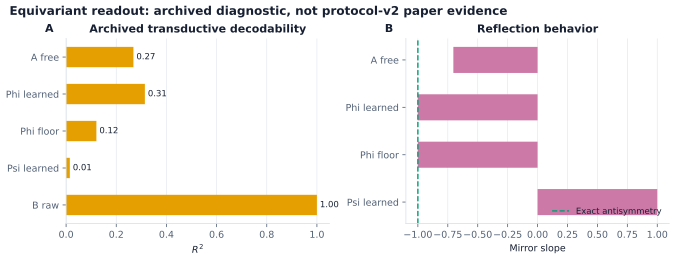

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_archived_equivariant_readout.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_equivariant_readout.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_equivariant_readout.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_archived_equivariant_readout.pdf


In [1]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "05c",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
